# LECTURE 11
**Topic:** Complex Matrices and Vectors  
**Textbook References:** Section 2.13

---

## Key Points

- For complex vectors: $\langle v,w\rangle = \sum_i v_i^* w_i = v^H w$ &emsp; (Hermitian inner product)
- $\|v\| = \langle v,v\rangle^{1/2}$
- The conjugate transpose $v^H = (v^*)^T$ replaces the transpose in real analysis.
- Projection, orthogonality, and least-squares work identically to the real case.


---
## Theory and Examples

### 1. Extension to Complex Vectors

All algebraic operations (addition, scaling, multiplication) extend to complex vectors using complex arithmetic.  
Gaussian elimination works the same way with complex numbers.

### 2. Norm of a Complex Vector

$$\|v\|^2 = \sum_{i=1}^m |v_i|^2 = \sum_{i=1}^m v_i^* v_i = v^H v$$

The **Hermitian** (conjugate transpose) operator: $v^H = (v^*)^T$.

### 3. Complex Inner Product

$$\langle v, w\rangle = \sum_{i=1}^m v_i^* w_i = v^H w$$

Note: **not symmetric** — $\langle w,v\rangle = \langle v,w\rangle^*$.

With scalar coefficients: $\langle \alpha v, \beta w\rangle = \alpha^* \beta \langle v,w\rangle$

> **Common Mistake:** Using $v^T w$ (without conjugation) for complex vectors — this is NOT the inner product and does NOT give $\|v\|^2$ when $w=v$.

### 4. Projection (Complex Case)

Same as real case but with Hermitian inner product:
$$c = \frac{\langle v,s\rangle}{\|v\|^2} \qquad c_j = \frac{\langle v^{(j)},s\rangle}{\|v^{(j)}\|^2}$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Example 5: The DFT matrix V for N=4
# Columns of V
N = 4
j = 1j
V = np.array([[1, 1, 1,  1],
              [1, j,-1, -j],
              [1,-1, 1, -1],
              [1,-j,-1,  j]], dtype=complex)

print('=== V matrix (N=4) ===')
print('V ='); print(V)

# Check VHV = 4I
VHV = V.conj().T @ V
print(f'\nV^H V ='); print(VHV.round(10))
print(f'V^H V == 4I? {np.allclose(VHV, 4*np.eye(N))}')

# Check column norms
for k in range(N):
    norm_k = np.linalg.norm(V[:,k])
    print(f'||v^({k})|| = {norm_k:.4f}  (should be 2)')

# Check pairwise orthogonality
print('\nInner products between columns:')
for k in range(N):
    for l in range(k+1,N):
        ip = V[:,k].conj() @ V[:,l]
        print(f'  <v^({k}),v^({l})> = {ip:.2e}  (should be 0)')

=== V matrix (N=4) ===
V =
[[ 1.+0.j  1.+0.j  1.+0.j  1.+0.j]
 [ 1.+0.j  0.+1.j -1.+0.j -0.-1.j]
 [ 1.+0.j -1.+0.j  1.+0.j -1.+0.j]
 [ 1.+0.j -0.-1.j -1.+0.j  0.+1.j]]

V^H V =
[[4.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 4.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 4.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 4.+0.j]]
V^H V == 4I? True
||v^(0)|| = 2.0000  (should be 2)
||v^(1)|| = 2.0000  (should be 2)
||v^(2)|| = 2.0000  (should be 2)
||v^(3)|| = 2.0000  (should be 2)

Inner products between columns:
  <v^(0),v^(1)> = 0.00e+00+0.00e+00j  (should be 0)
  <v^(0),v^(2)> = 0.00e+00+0.00e+00j  (should be 0)
  <v^(0),v^(3)> = 0.00e+00+0.00e+00j  (should be 0)
  <v^(1),v^(2)> = 0.00e+00+0.00e+00j  (should be 0)
  <v^(1),v^(3)> = 0.00e+00+0.00e+00j  (should be 0)
  <v^(2),v^(3)> = 0.00e+00+0.00e+00j  (should be 0)


In [2]:
# Example 6: Represent vector s = [-3,1,1,9] in terms of columns of V
s = np.array([-3,1,1,9], dtype=complex)

# c = V^H s / N
c_vec = V.conj().T @ s / N

print('=== Represent s = [-3,1,1,9] as s = V*c ===')
print(f's = {s}')
print(f'c = V^H s / 4 = {c_vec}  (should be [2, -1+2j, -3, -1-2j])')

# Verify
s_reconstructed = V @ c_vec
print(f'V*c = {s_reconstructed.round(10)}  (should match s)')
print(f'Match? {np.allclose(s_reconstructed, s)}')

# Example 8: compute ||s||^2 in two ways
norm_s_sq_direct = np.linalg.norm(s)**2
norm_s_sq_via_c  = sum(abs(c_vec[j])**2 * 4 for j in range(N))  # * ||v^k||^2 = 4
print(f'\n||s||^2 directly    = {norm_s_sq_direct}')
print(f'||s||^2 via c       = {norm_s_sq_via_c.real}')
print(f'(should be (-3)^2+1^2+1^2+9^2 = {9+1+1+81})')

# Compute inner product <s,x> directly and via coordinates
x_vec = V @ np.array([1,-1,3,1], dtype=complex)
ip_direct = s.conj() @ x_vec
d_vec = np.array([1,-1,3,1], dtype=complex)
ip_via_c = sum(c_vec[j].conj() * d_vec[j] * 4 for j in range(N))
print(f'\n<s,x> directly = {ip_direct}')
print(f'<s,x> via c    = {ip_via_c}  (should be -28+16j)')

=== Represent s = [-3,1,1,9] as s = V*c ===
s = [-3.+0.j  1.+0.j  1.+0.j  9.+0.j]
c = V^H s / 4 = [ 2.+0.j -1.+2.j -3.+0.j -1.-2.j]  (should be [2, -1+2j, -3, -1-2j])
V*c = [-3.+0.j  1.+0.j  1.+0.j  9.+0.j]  (should match s)
Match? True

||s||^2 directly    = 91.99999999999999
||s||^2 via c       = 92.0
(should be (-3)^2+1^2+1^2+9^2 = 92)

<s,x> directly = (-28+16j)
<s,x> via c    = (-28+16j)  (should be -28+16j)


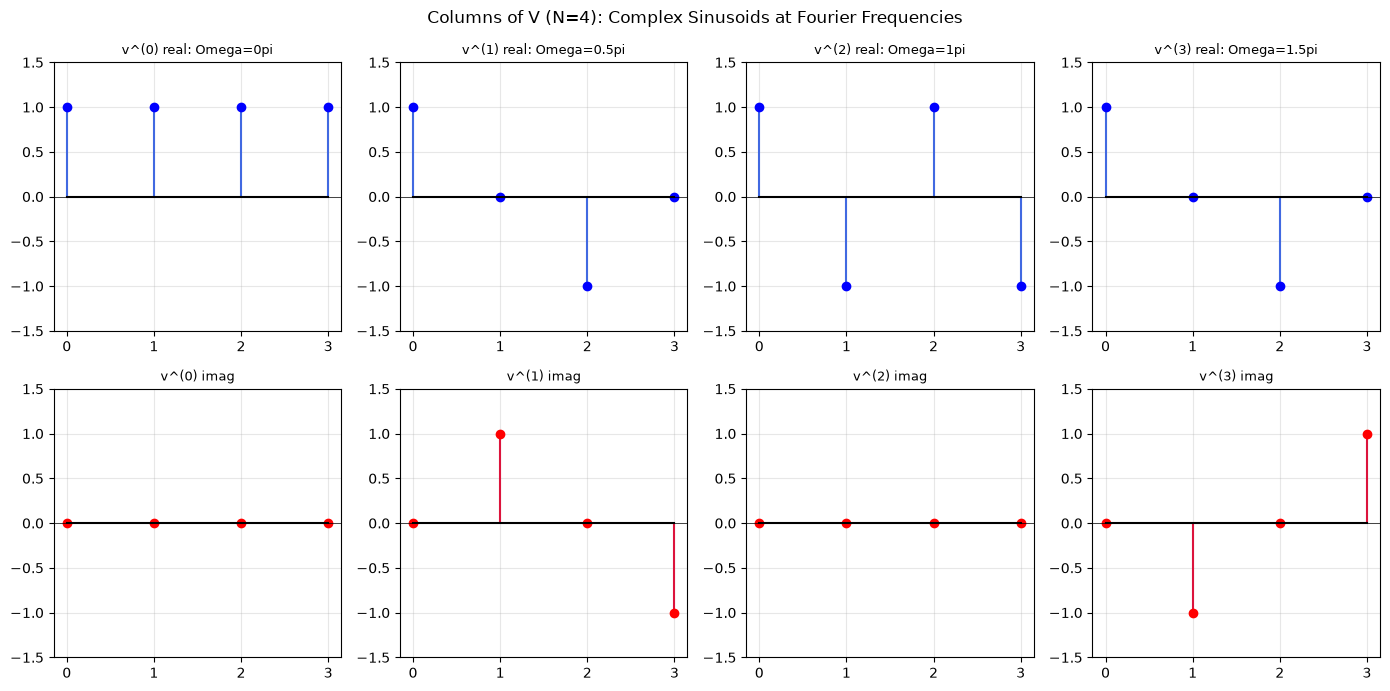

In [3]:
# Visualize DFT-4 columns as complex sinusoids
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
n = np.arange(N)
omega_vals = [0, np.pi/2, np.pi, 3*np.pi/2]

for k in range(N):
    col = V[:,k]
    omega_k = k * 2*np.pi/N
    # Real part (cosine)
    ax = axes[0][k]
    ax.stem(n, col.real, linefmt='royalblue', markerfmt='bo', basefmt='k')
    ax.axhline(0, color='k',lw=0.5); ax.grid(True,alpha=0.3)
    ax.set_title(f'v^({k}) real: Omega={omega_vals[k]/np.pi:.2g}pi', fontsize=9)
    ax.set_ylim(-1.5,1.5)
    # Imaginary part (sine)
    ax = axes[1][k]
    ax.stem(n, col.imag, linefmt='crimson', markerfmt='ro', basefmt='k')
    ax.axhline(0, color='k',lw=0.5); ax.grid(True,alpha=0.3)
    ax.set_title(f'v^({k}) imag', fontsize=9)
    ax.set_ylim(-1.5,1.5)

plt.suptitle('Columns of V (N=4): Complex Sinusoids at Fourier Frequencies', fontsize=12)
plt.tight_layout(); plt.show()

---
### 7. Change of Coordinates

Expressing $s = Vc$ changes the coordinate system to the **columns of $V$** (new axes).  
For orthogonal columns:
$$\|s\|^2 = \sum_{j=1}^m |c_j|^2 \cdot \|v^{(j)}\|^2$$

Inner products can also be computed in the new coordinates:
$$\langle s, x\rangle = \sum_{j=1}^m c_j^* d_j \cdot \|v^{(j)}\|^2$$

where $s=Vc$ and $x=Vd$.

### 9-10. The DFT Matrix

The $N=4$ matrix $V$ is the simplest DFT matrix. The DFT is the set of inner products $\langle v^{(k)},s\rangle$, where:  
- The $n$-th entry of $v^{(k)}$ is $e^{j\Omega_k n}$ with $\Omega_k = k(2\pi/N)$.
- These $N$ sinusoids have fundamental periods $1, N, N/2, \ldots$ and all repeat every $N$ samples.
- They form an orthogonal basis for $\mathbb{C}^N$.


---
## Summary

| Real vectors | Complex vectors |
|---|---|
| $\langle a,b\rangle = a^Tb$ | $\langle v,w\rangle = v^Hw$ |
| $\|a\|^2 = a^Ta$ | $\|v\|^2 = v^Hv$ |
| Symmetric: $\langle a,b\rangle=\langle b,a\rangle$ | Conjugate: $\langle v,w\rangle=\langle w,v\rangle^*$ |
| Projection: $c=a^Tb/\|a\|^2$ | Projection: $c=v^Hs/\|v\|^2$ |

### Mistakes to Avoid
1. Using $v^T w$ instead of $v^H w$ for complex vectors — this gives wrong results.
2. Complex inner product is **not** commutative: $\langle v,w\rangle = \langle w,v\rangle^*$.
3. $\langle \alpha v, w\rangle = \alpha^* \langle v,w\rangle$ — the scalar on the **first** argument gets conjugated.
